In [14]:
import os
import glob
import uuid
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from transformers import AutoImageProcessor, AutoModel

import warnings
warnings.filterwarnings('ignore')

In [15]:
CONFIG = {
    "base_dir": "Skin_cancer_dataset",
    "csv_name": "HAM10000_metadata.csv",
    "part1_dir": "HAM10000_images_part_1",
    "part2_dir": "HAM10000_images_part_2",
    "benign_dir": "benign",
    "model_name": "microsoft/swin-tiny-patch4-window7-224",
    "test_size": 0.20,
    "batch_size": 16,
    "head_lr": 1e-3,
    "fine_tune_lr": 2e-5,
    "head_epochs": 3,
    "fine_tune_epochs": 4,
    "weight_decay": 0.01,
    "seed": 42
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = AutoImageProcessor.from_pretrained(CONFIG["model_name"])

preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

In [16]:
csv_path = os.path.join(CONFIG["base_dir"], CONFIG["csv_name"])
part1_paths = glob.glob(os.path.join(CONFIG["base_dir"], CONFIG["part1_dir"], "*.jpg"))
part2_paths = glob.glob(os.path.join(CONFIG["base_dir"], CONFIG["part2_dir"], "*.jpg"))
image_path_map = {os.path.splitext(os.path.basename(p))[0]: p for p in part1_paths + part2_paths}

df = pd.read_csv(csv_path)
df['path'] = df['image_id'].map(image_path_map)
df = df.dropna(subset=['path']).reset_index(drop=True)

lesion_dict = {
    'nv': 'Melanocytic nevi', 'mel': 'Melanoma', 'bkl': 'Benign keratosis', 
    'bcc': 'Basal cell carcinoma', 'akiec': 'Actinic keratoses', 
    'vasc': 'Vascular lesions', 'df': 'Dermatofibroma'
}
df['cell_type'] = df['dx'].map(lesion_dict)

benign_paths = glob.glob(os.path.join(CONFIG["base_dir"], CONFIG["benign_dir"], "*.*"))
df_benign = pd.DataFrame({
    'image_id': [f"benign_{i}" for i in range(len(benign_paths))],
    'dx': 'none',
    'lesion_id': [str(uuid.uuid4()) for _ in range(len(benign_paths))],
    'path': benign_paths,
    'cell_type': 'Not a Lesion'
})

df_combined = pd.concat([df, df_benign], ignore_index=True)
df_combined['label'] = pd.Categorical(df_combined['cell_type']).codes
class_names = list(pd.Categorical(df_combined['cell_type']).categories)

unique_lesions = df_combined['lesion_id'].unique()
train_lesions, val_lesions = train_test_split(unique_lesions, test_size=CONFIG["test_size"], random_state=CONFIG["seed"])

train_df = df_combined[df_combined['lesion_id'].isin(train_lesions)].reset_index(drop=True)
val_df = df_combined[df_combined['lesion_id'].isin(val_lesions)].reset_index(drop=True)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

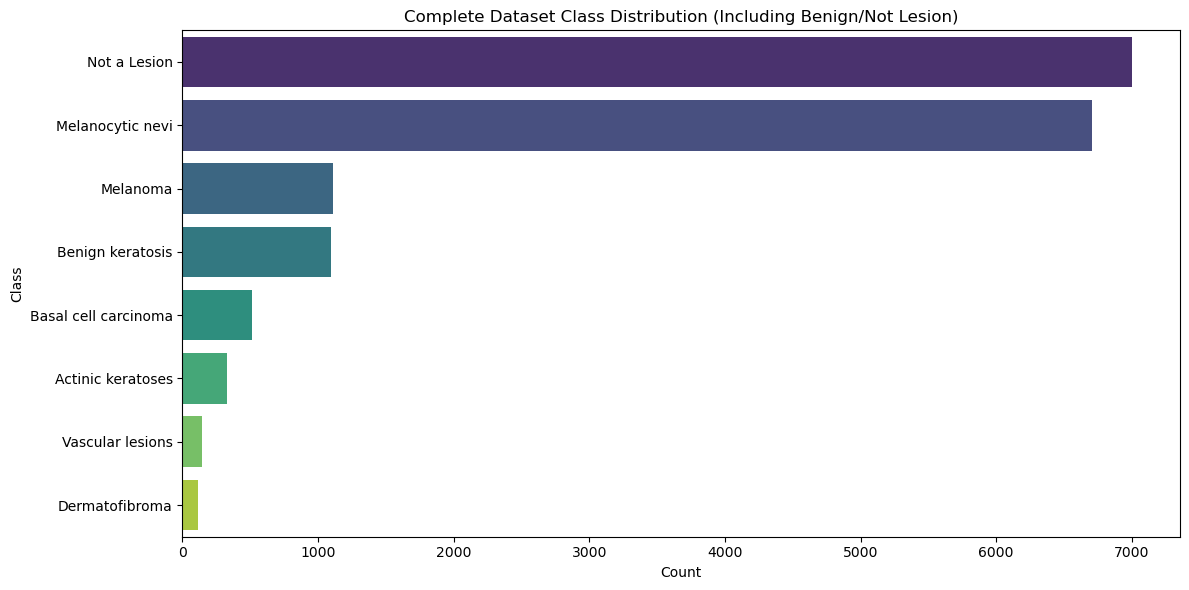

In [17]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_combined, y='cell_type', order=df_combined['cell_type'].value_counts().index, palette='viridis')
plt.title('Complete Dataset Class Distribution (Including Benign/Not Lesion)')
plt.xlabel('Count')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

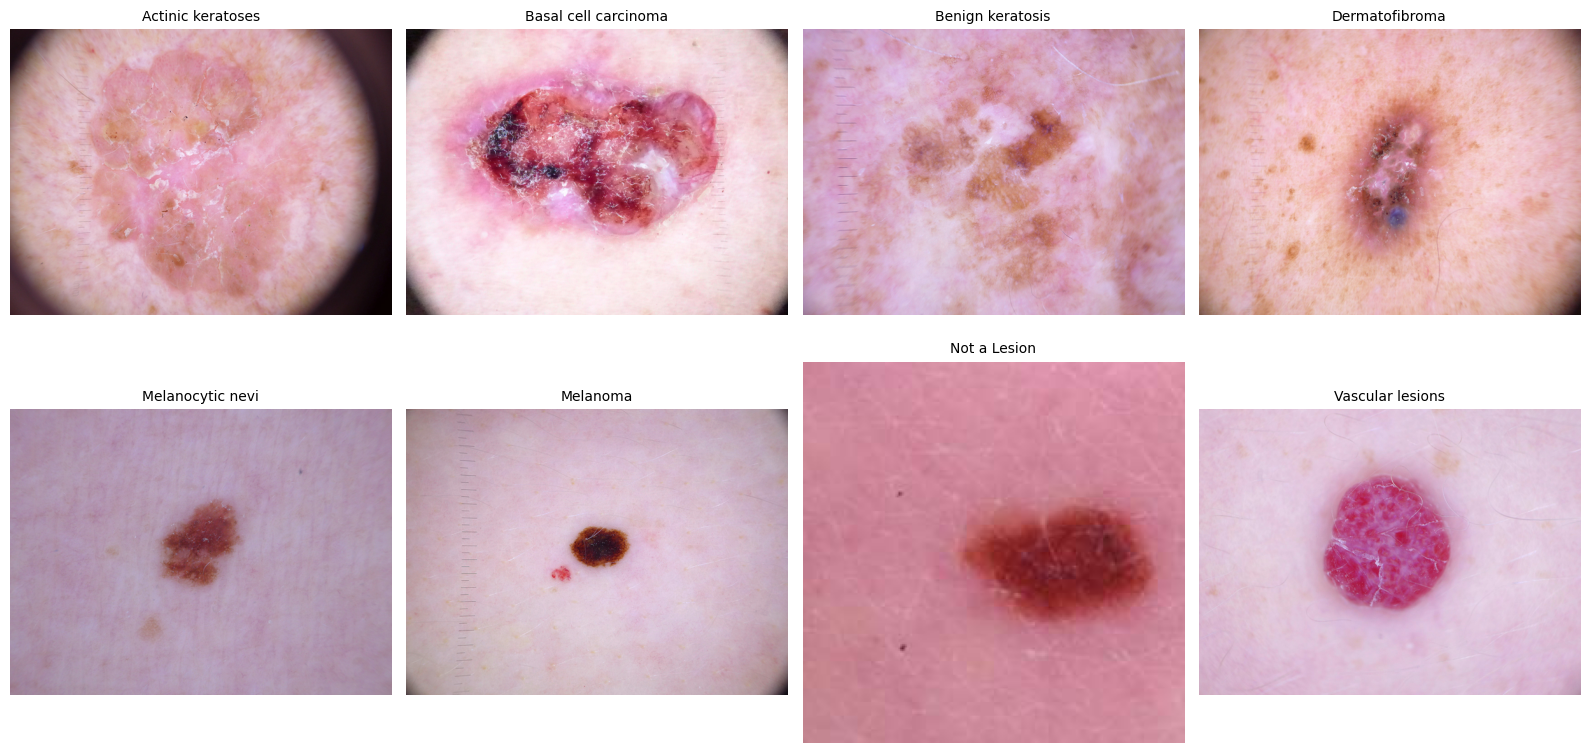

In [18]:
num_classes = len(class_names)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, class_name in enumerate(class_names):
    sample_path = df_combined[df_combined['cell_type'] == class_name].iloc[0]['path']
    img = Image.open(sample_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(class_name, fontsize=10)
    axes[i].axis('off')

for j in range(num_classes, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [19]:
class SkinCancerDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df
        self.processor = processor
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'path']
        label = self.df.loc[idx, 'label']
        image = Image.open(img_path).convert('RGB')
        inputs = self.processor(images=image, return_tensors="pt")
        return inputs['pixel_values'].squeeze(0), torch.tensor(label, dtype=torch.long)

train_dataset = SkinCancerDataset(train_df, processor)
val_dataset = SkinCancerDataset(val_df, processor)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0, pin_memory=True)

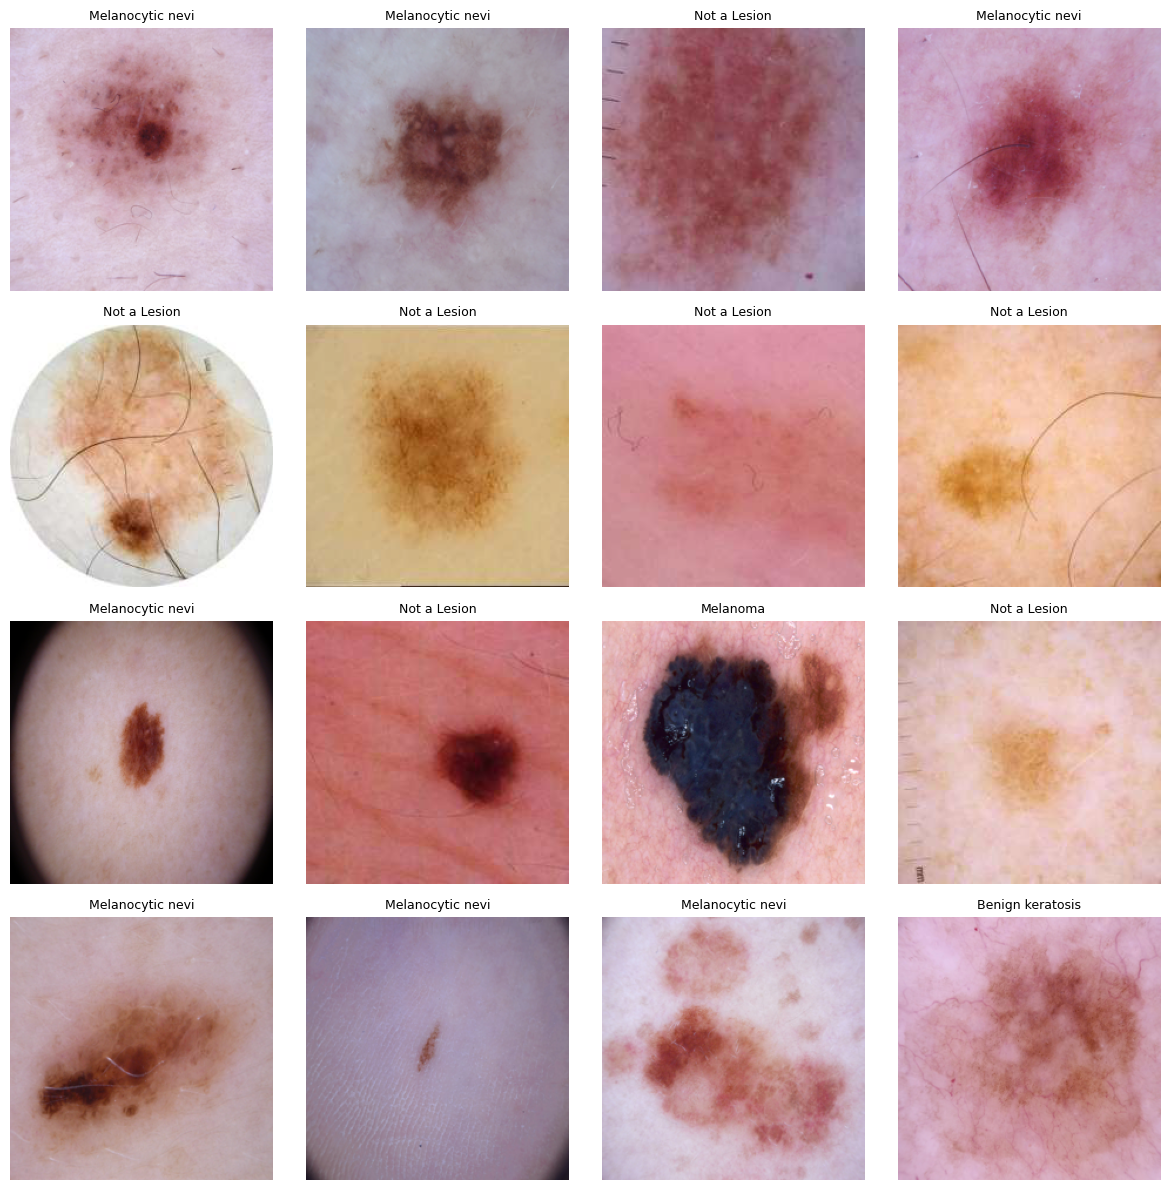

In [20]:
batch_images, batch_labels = next(iter(train_loader))

pixel_mean = torch.tensor(processor.image_mean).view(3, 1, 1)
pixel_std = torch.tensor(processor.image_std).view(3, 1, 1)
unnormalized_images = batch_images * pixel_std + pixel_mean
unnormalized_images = torch.clamp(unnormalized_images, 0, 1)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i in range(16):
    if i < len(batch_images):
        img = unnormalized_images[i].permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(class_names[batch_labels[i].item()], fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [21]:
class ViTClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        in_features = self.backbone.config.hidden_size
        
        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(0.3),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        features = outputs.pooler_output 
        return self.head(features)

model = ViTClassifier(CONFIG["model_name"], len(class_names)).to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

[transformers] SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
# Use the standard text-based tqdm to prevent Jupyter rendering bugs
from tqdm import tqdm 

def execute_epoch(model, loader, criterion, optimizer=None, scaler=None, is_train=True):
    if is_train:
        model.train()
    else:
        model.eval()
        
    running_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()
    
    with context:
        # 1. Assign the progress bar to a variable
        pbar = tqdm(loader, desc="Train" if is_train else "Val", leave=False)
        
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            if is_train:
                optimizer.zero_grad()
                
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(images)
                loss = criterion(outputs, labels)
                
            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                
            # Track metrics
            loss_val = loss.item()
            running_loss += loss_val * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            # 2. LIVE UPDATE: This forces the progress bar to show the math happening!
            current_acc = correct / total
            pbar.set_postfix({'loss': f"{loss_val:.4f}", 'acc': f"{current_acc:.4f}"})
            
    return running_loss / total, correct / total

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
scaler = torch.amp.GradScaler('cuda')
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

In [23]:
for param in model.backbone.parameters():
    param.requires_grad = False

optimizer_head = torch.optim.AdamW(model.head.parameters(), lr=CONFIG["head_lr"], weight_decay=CONFIG["weight_decay"])
best_val_acc = 0.0

for epoch in range(1, CONFIG["head_epochs"] + 1):
    t_loss, t_acc = execute_epoch(model, train_loader, criterion, optimizer_head, scaler, is_train=True)
    v_loss, v_acc = execute_epoch(model, val_loader, criterion, is_train=False)
    
    history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc); history["val_acc"].append(v_acc)
    
    print(f"Phase 1 - Epoch {epoch}/{CONFIG['head_epochs']} | T-Loss: {t_loss:.4f} | T-Acc: {t_acc:.4f} | V-Loss: {v_loss:.4f} | V-Acc: {v_acc:.4f}")

Phase 1 - Epoch 1/3 | T-Loss: 1.1772 | T-Acc: 0.7399 | V-Loss: 0.5128 | V-Acc: 0.8159


Phase 1 - Epoch 2/3 | T-Loss: 0.9242 | T-Acc: 0.7799 | V-Loss: 0.5392 | V-Acc: 0.7996


Phase 1 - Epoch 3/3 | T-Loss: 0.8625 | T-Acc: 0.7923 | V-Loss: 0.5276 | V-Acc: 0.8082


In [24]:
for param in model.backbone.parameters():
    param.requires_grad = True

optimizer_full = torch.optim.AdamW(model.parameters(), lr=CONFIG["fine_tune_lr"], weight_decay=CONFIG["weight_decay"])

for epoch in range(1, CONFIG["fine_tune_epochs"] + 1):
    t_loss, t_acc = execute_epoch(model, train_loader, criterion, optimizer_full, scaler, is_train=True)
    v_loss, v_acc = execute_epoch(model, val_loader, criterion, is_train=False)
    
    history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc); history["val_acc"].append(v_acc)
    
    print(f"Phase 2 - Epoch {epoch}/{CONFIG['fine_tune_epochs']} | T-Loss: {t_loss:.4f} | T-Acc: {t_acc:.4f} | V-Loss: {v_loss:.4f} | V-Acc: {v_acc:.4f}")
    
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), "vit_final_weights.pth")

Phase 2 - Epoch 1/4 | T-Loss: 0.6919 | T-Acc: 0.8194 | V-Loss: 0.3698 | V-Acc: 0.8745


Phase 2 - Epoch 2/4 | T-Loss: 0.4656 | T-Acc: 0.8637 | V-Loss: 0.3816 | V-Acc: 0.8573


Phase 2 - Epoch 3/4 | T-Loss: 0.3207 | T-Acc: 0.8950 | V-Loss: 0.3169 | V-Acc: 0.8845


Phase 2 - Epoch 4/4 | T-Loss: 0.2684 | T-Acc: 0.9103 | V-Loss: 0.3608 | V-Acc: 0.8739


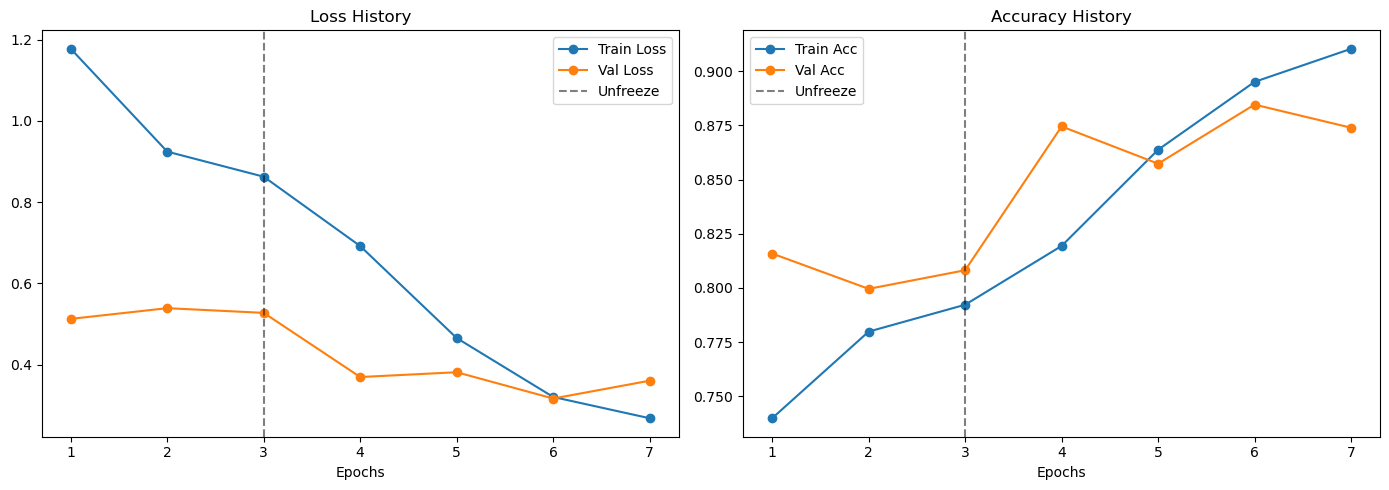

In [25]:
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history["train_loss"], label='Train Loss', marker='o')
ax1.plot(epochs_range, history["val_loss"], label='Val Loss', marker='o')
ax1.axvline(x=CONFIG["head_epochs"], color='black', linestyle='--', alpha=0.5, label='Unfreeze')
ax1.set_title('Loss History')
ax1.set_xlabel('Epochs')
ax1.legend()

ax2.plot(epochs_range, history["train_acc"], label='Train Acc', marker='o')
ax2.plot(epochs_range, history["val_acc"], label='Val Acc', marker='o')
ax2.axvline(x=CONFIG["head_epochs"], color='black', linestyle='--', alpha=0.5, label='Unfreeze')
ax2.set_title('Accuracy History')
ax2.set_xlabel('Epochs')
ax2.legend()

plt.tight_layout()
plt.show()

Generating Predictions: 100%|████████████████████████████████████████████████████████| 212/212 [00:53<00:00,  3.94it/s]


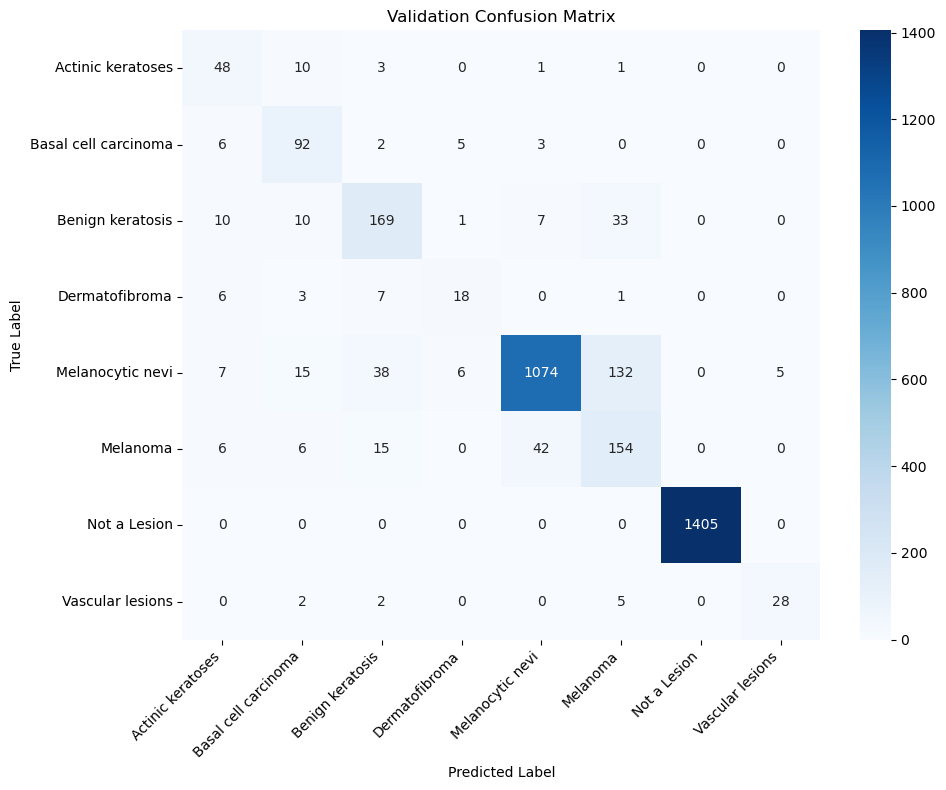

                      precision    recall  f1-score   support

   Actinic keratoses       0.58      0.76      0.66        63
Basal cell carcinoma       0.67      0.85      0.75       108
    Benign keratosis       0.72      0.73      0.73       230
      Dermatofibroma       0.60      0.51      0.55        35
    Melanocytic nevi       0.95      0.84      0.89      1277
            Melanoma       0.47      0.69      0.56       223
        Not a Lesion       1.00      1.00      1.00      1405
    Vascular lesions       0.85      0.76      0.80        37

            accuracy                           0.88      3378
           macro avg       0.73      0.77      0.74      3378
        weighted avg       0.90      0.88      0.89      3378



In [26]:
model.load_state_dict(torch.load("vit_final_weights.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Generating Predictions"):
        images = images.to(device)
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Validation Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))